# CosmoFit Model Zoo: 6 Cosmological Models Head-to-Head

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/salihyesil59/CosmoFit/blob/main/examples/model_zoo_comparison.ipynb)

CosmoFit ships six background-expansion models:

| Model | Dark energy | Free params |
|---|---|---|
| **LCDM** | cosmological constant, w=-1 | H0, Om |
| **wCDM** | constant w0 | H0, Om, w0 |
| **CPL** | w(z) = w0 + wa z/(1+z) | H0, Om, w0, wa |
| **JBP** | w(z) = w0 + wa z/(1+z)^2 | H0, Om, w0, wa |
| **BA** | w(z) = w0 + wa z(1+z)/(1+z^2) | H0, Om, w0, wa |
| **GCG** | unified DM/DE fluid, p=-A/rho^alpha | H0, Om, A_s, alpha |

This notebook fits all six to the same data (Cosmic Chronometers +
DESI BAO + DES-SN5YR) and compares them with AIC/BIC, then takes a
closer look at the most novel one (GCG) with a full MCMC.

**Running this notebook:** open in Colab and *Runtime → Run all*
(~3-4 minutes).


## Setup

In [1]:
import sys, os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    if not os.path.exists("CosmoFit"):
        !git clone --quiet -b dev https://github.com/salihyesil59/CosmoFit.git
    %cd CosmoFit
    !pip install -q -e .
else:
    print("Not running in Colab -- assuming CosmoFit is already installed "
          "(pip install -e . from the repository root).")


Not running in Colab -- assuming CosmoFit is already installed (pip install -e . from the repository root).


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from CosmoFit import LCDM, WCDM, CPL, JBP, BA, GCG, Fitter
from CosmoFit.stats import model_comparison

%matplotlib inline
plt.rcParams["figure.dpi"] = 110
np.random.seed(0)

DATASETS = ["cc", "desi", "des_sn5yr"]
INITIAL = {
    "H0": 67.4, "Omega_m": 0.315, "w0": -1.0, "wa": 0.0,
    "A_s": 0.7, "alpha": 0.0, "rd": 147.1,
}

MODELS = {
    "LCDM": (LCDM, ["H0", "Omega_m"]),
    "wCDM": (WCDM, ["H0", "Omega_m", "w0"]),
    "CPL":  (CPL,  ["H0", "Omega_m", "w0", "wa"]),
    "JBP":  (JBP,  ["H0", "Omega_m", "w0", "wa"]),
    "BA":   (BA,   ["H0", "Omega_m", "w0", "wa"]),
    "GCG":  (GCG,  ["H0", "Omega_m", "A_s", "alpha"]),
}

## Fit all six models (best-fit only -- no MCMC yet)

A best-fit search (`scipy.optimize.minimize`) is enough to compare
models with AIC/BIC; we'll only run a full MCMC for the one we want
posterior samples from.

In [3]:
fits = {}
rows = []

for name, (model_cls, free_params) in MODELS.items():
    fit = Fitter(
        model=model_cls,
        datasets=DATASETS,
        free_params=free_params,
        initial=INITIAL,
    )
    fit.best_fit()
    fits[name] = fit
    rows.append({
        "model": name,
        "k": fit.ndim,
        "chi2": fit.best_fit_chi2,
        "AIC": model_comparison.aic(fit.best_fit_chi2, fit.ndim),
        "BIC": model_comparison.bic(fit.best_fit_chi2, fit.ndim, fit.n_data),
        **fit.best_fit_params,
    })
    print(f"{name:>5s}  chi2={fit.best_fit_chi2:8.2f}  k={fit.ndim}  "
          f"params={ {k: round(v, 3) for k, v in fit.best_fit_params.items()} }")

results = pd.DataFrame(rows).set_index("model")
results

 LCDM  chi2= 1660.25  k=2  params={'H0': np.float64(68.357), 'Omega_m': np.float64(0.312)}


 wCDM  chi2= 1656.54  k=3  params={'H0': np.float64(67.983), 'Omega_m': np.float64(0.295), 'w0': np.float64(-0.909)}


  CPL  chi2= 1653.60  k=4  params={'H0': np.float64(67.827), 'Omega_m': np.float64(0.323), 'w0': np.float64(-0.788), 'wa': np.float64(-1.071)}


  JBP  chi2= 1653.45  k=4  params={'H0': np.float64(67.732), 'Omega_m': np.float64(0.317), 'w0': np.float64(-0.729), 'wa': np.float64(-1.697)}


   BA  chi2= 1653.79  k=4  params={'H0': np.float64(67.906), 'Omega_m': np.float64(0.323), 'w0': np.float64(-0.834), 'wa': np.float64(-0.525)}


  GCG  chi2= 1657.11  k=4  params={'H0': np.float64(68.017), 'Omega_m': np.float64(0.05), 'A_s': np.float64(0.687), 'alpha': np.float64(-0.15)}


,k,chi2,AIC,BIC,H0,Omega_m,w0,wa,A_s,alpha
model,,,,,,,,,,
LCDM,2,1660.245561,1664.245561,1675.306521,68.356937,0.311700,NaN,NaN,NaN,NaN
wCDM,3,1656.536011,1662.536011,1679.127451,67.983311,0.294984,-0.909056,NaN,NaN,NaN
CPL,4,1653.597703,1661.597703,1683.719623,67.826605,0.323252,-0.788123,-1.071486,NaN,NaN
JBP,4,1653.446628,1661.446628,1683.568548,67.731966,0.317001,-0.729158,-1.697154,NaN,NaN
BA,4,1653.793928,1661.793928,1683.915848,67.905872,0.322871,-0.833632,-0.525068,NaN,NaN
GCG,4,1657.113566,1665.113566,1687.235486,68.017340,0.050000,NaN,NaN,0.687277,-0.150051


**A note on the GCG row above:** its best-fit `Omega_m` came out
very low (near the prior floor) -- this is a real, known GCG
degeneracy, not a bug: the Chaplygin fluid itself behaves like
matter at high redshift (see the class docstring), so it can trade
off against `Omega_m` along a partly-degenerate direction. The full
MCMC posterior below finds a rather different `Omega_m` than this
best-fit point for exactly that reason -- a good illustration of why
a single best-fit point estimate is not enough for a model like this,
and `fit.convergence()` / the corner plot matter more than usual
here.

## AIC / BIC relative to LCDM

Negative = preferred over LCDM (lower information criterion is
better); positive = LCDM still wins once the extra free parameters
are penalized.

In [4]:
baseline_aic = results.loc["LCDM", "AIC"]
baseline_bic = results.loc["LCDM", "BIC"]

delta = pd.DataFrame({
    "delta_AIC": results["AIC"] - baseline_aic,
    "delta_BIC": results["BIC"] - baseline_bic,
})
delta

,delta_AIC,delta_BIC
model,,
LCDM,0.000000,0.000000
wCDM,-1.709550,3.820930
CPL,-2.647858,8.413102
JBP,-2.798932,8.262028
BA,-2.451632,8.609328
GCG,0.868005,11.928965


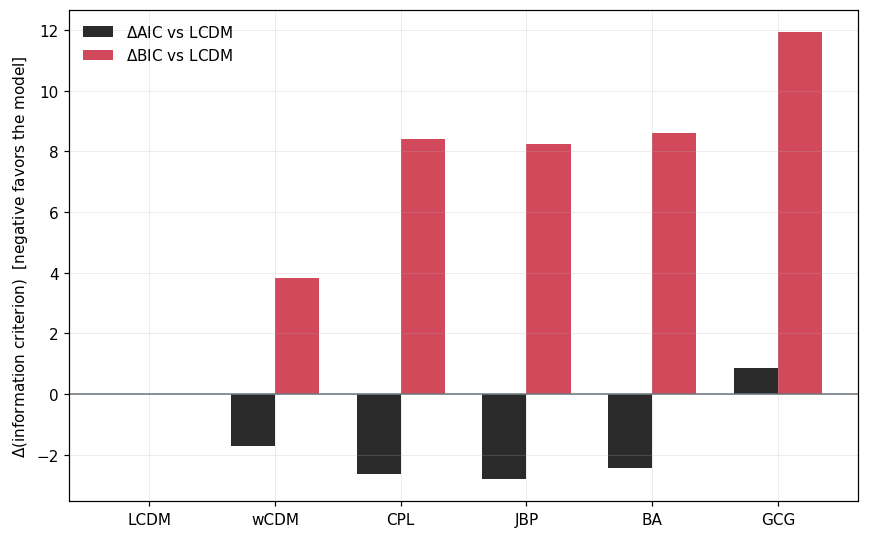

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(delta))
width = 0.35

ax.bar(x - width/2, delta["delta_AIC"], width, label=r"$\Delta$AIC vs LCDM", color="#2b2b2b")
ax.bar(x + width/2, delta["delta_BIC"], width, label=r"$\Delta$BIC vs LCDM", color="#d1495b")
ax.axhline(0.0, color="#6c757d", lw=1.0)
ax.set_xticks(x)
ax.set_xticklabels(delta.index)
ax.set_ylabel(r"$\Delta$(information criterion)  [negative favors the model]")
ax.legend(frameon=False)
ax.grid(alpha=0.25, linewidth=0.6)
fig.tight_layout()

## Dark-energy equation of state: w(z) for every model

All five non-LCDM models define `.w(z)`, evaluated here at each
model's own best-fit point (no posterior band -- just point
estimates, to compare shapes).

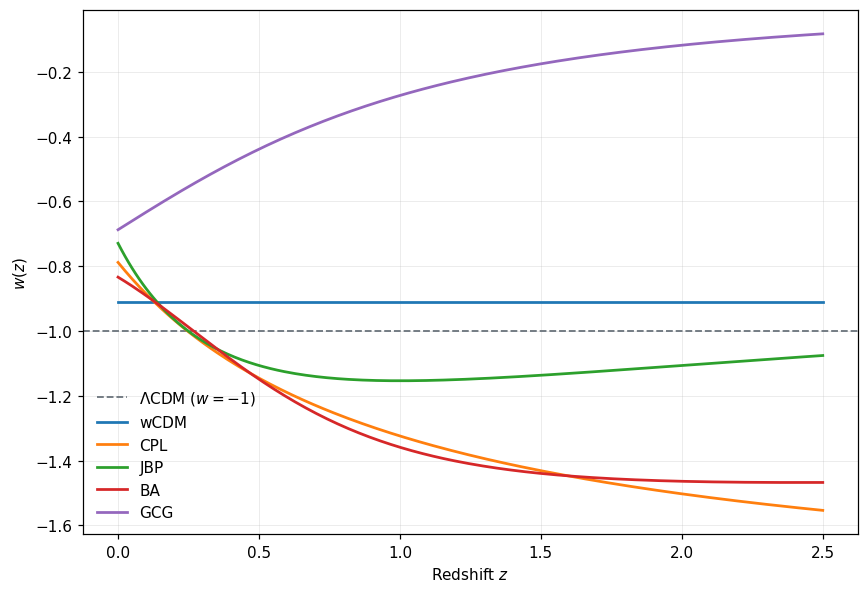

In [6]:
z = np.linspace(0.0, 2.5, 200)

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.axhline(-1.0, color="#6c757d", lw=1.2, ls="--", label=r"$\Lambda$CDM ($w=-1$)")

for name in ("wCDM", "CPL", "JBP", "BA", "GCG"):
    fit = fits[name]
    w = fit.cosmology.w(z)
    ax.plot(z, w, lw=1.8, label=name)

ax.set_xlabel("Redshift $z$")
ax.set_ylabel("$w(z)$")
ax.legend(frameon=False)
ax.grid(alpha=0.25, linewidth=0.6)
fig.tight_layout()

## A closer look at GCG: full MCMC

GCG replaces dark energy entirely with a single fluid (the
Generalized Chaplygin Gas) that behaves like matter at early times
and like a cosmological constant at late times. `A_s` (equal to
`-w(z=0)`) and `alpha` are its two free parameters; `A_s=1` reduces
GCG to LCDM exactly, for any `alpha`.

In [7]:
gcg_fit = Fitter(
    model=GCG,
    datasets=DATASETS,
    free_params=["H0", "Omega_m", "A_s", "alpha"],
    initial=INITIAL,
)

gcg_fit.run_mcmc(nwalkers=24, nsteps=1500, burnin=300, seed=0, progress=True)

  0%|          | 0/1500 [00:00<?, ?it/s]

  0%|          | 5/1500 [00:00<00:36, 41.47it/s]

  1%|          | 10/1500 [00:00<00:36, 40.45it/s]

  1%|          | 15/1500 [00:00<00:37, 39.42it/s]

  1%|▏         | 19/1500 [00:00<00:38, 38.15it/s]

...

 99%|█████████▊| 1479/1500 [00:33<00:00, 49.34it/s]

 99%|█████████▉| 1485/1500 [00:33<00:00, 50.85it/s]

 99%|█████████▉| 1491/1500 [00:33<00:00, 49.99it/s]

100%|█████████▉| 1497/1500 [00:33<00:00, 48.99it/s]

100%|██████████| 1500/1500 [00:33<00:00, 44.36it/s]

The chain is shorter than 50 times the integrated autocorrelation time for 4 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 30;
tau: [ 54.90908552 103.39841569  93.01059439  99.78726888]


converged: False
        H0 = 67.9860 +0.6817 / -0.6335
   Omega_m = 0.2601 +0.0334 / -0.1098
       A_s = 0.8719 +0.0666 / -0.1045
     alpha = -0.3591 +0.2069 / -0.3712


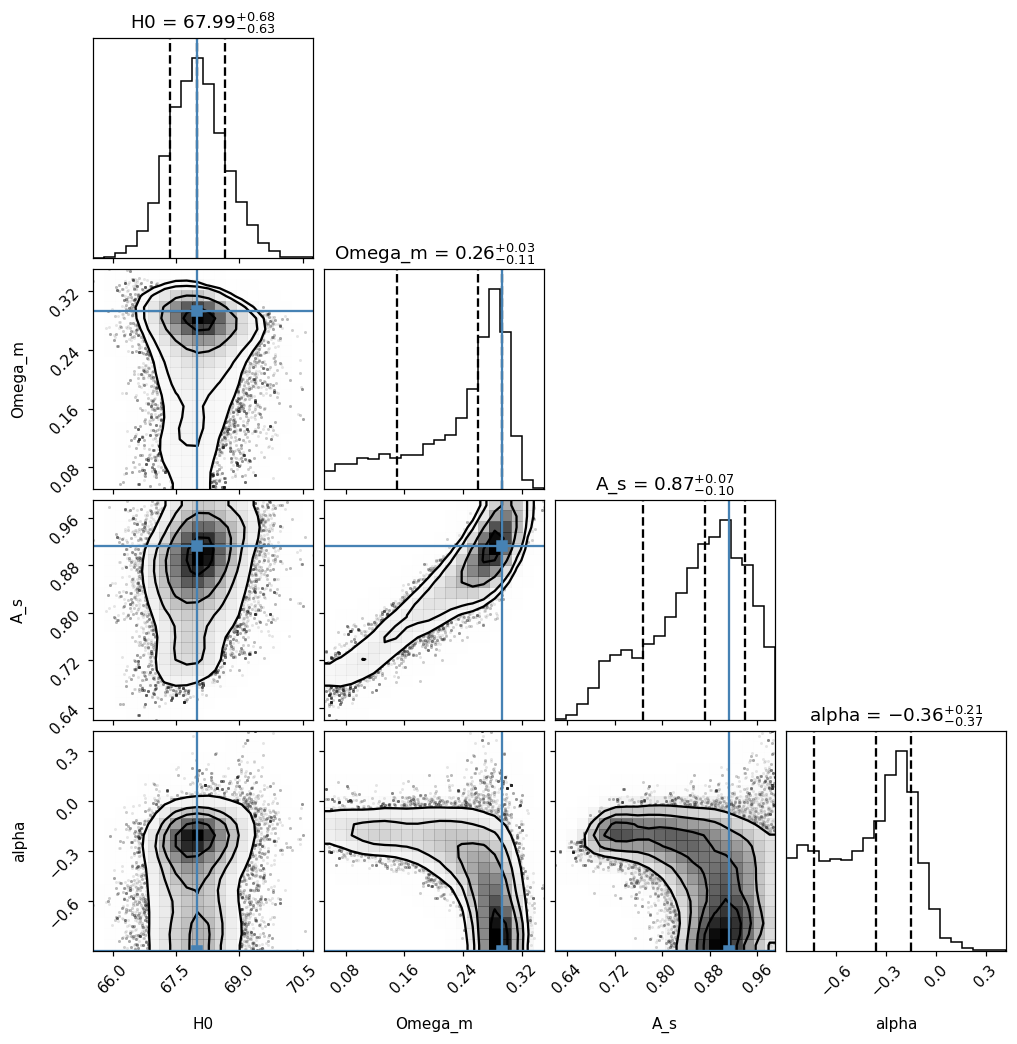

In [8]:
conv = gcg_fit.convergence()
print(f"converged: {conv['converged']}")

for name, s in gcg_fit.summary().items():
    print(f"{name:>10s} = {s['median']:.4f} +{s['plus']:.4f} / -{s['minus']:.4f}")

gcg_fit.best_fit()

fig = gcg_fit.plots.corner(truths=[
    gcg_fit.best_fit_params["H0"],
    gcg_fit.best_fit_params["Omega_m"],
    gcg_fit.best_fit_params["A_s"],
    gcg_fit.best_fit_params["alpha"],
])

In [9]:
samples = gcg_fit.samples_dict()
p_lcdm_limit = (samples["A_s"] > 0.98).mean()
print(f"Fraction of the GCG posterior with A_s > 0.98 "
      f"(i.e. essentially indistinguishable from LCDM): {p_lcdm_limit:.1%}")

Fraction of the GCG posterior with A_s > 0.98 (i.e. essentially indistinguishable from LCDM): 1.7%


## Summary

- AIC/BIC comparisons like this one are only ever relative to the
  *specific* datasets used -- rerun with `"pantheon"` instead of
  `"des_sn5yr"`, or add `"planck"`/`"sdss_bao"`, and the ranking can
  shift (see [`dataset_zoo.ipynb`](dataset_zoo.ipynb) for what each
  dataset looks like on its own, and which combinations to avoid).
- A model with more free parameters will essentially always reach a
  lower chi2 at its best fit; AIC/BIC exist specifically to penalize
  that. `delta_BIC` penalizes extra parameters more harshly than
  `delta_AIC` and is usually the more conservative one to trust.
- None of this replaces checking `fit.convergence()` before trusting
  any of these numbers -- a short demo MCMC (like the GCG one above)
  may not have fully converged; rerun with more steps for
  publication-quality results.

See [`cpl_mcmc_analysis.ipynb`](cpl_mcmc_analysis.ipynb) for a deeper
single-model analysis (convergence diagnostics, every `fit.plots`
figure, a Planck cross-check) and
[`dataset_zoo.ipynb`](dataset_zoo.ipynb) for a tour of every
dataset.